# Encoding a shape as the mean of SSP embeddings

Ssample `n_datapts` points uniformly inside a shape (5-point star right now),
encodes each point with a Spatial Semantic Pointer (SSP) encoding
(`vsagym.spaces.HexagonalSSPSpace`), and takes the mean of the resulting
embeddings. 

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Circle, Ellipse, PathPatch, RegularPolygon
from vsagym.spaces import HexagonalSSPSpace

rng = np.random.default_rng(seed=0)

## Define a shape and sample points inside it

The shape is any matplotlib patch (here a 5-point star from
`Path.unit_regular_star`). Swap the `shape = ...` line for a different patch —
`Circle`, `Ellipse`, `RegularPolygon`, or a `PathPatch` around any custom
`Path` — to change the region. Points are drawn by rejection sampling: sample
uniformly from the shape's bounding box and keep the ones inside.

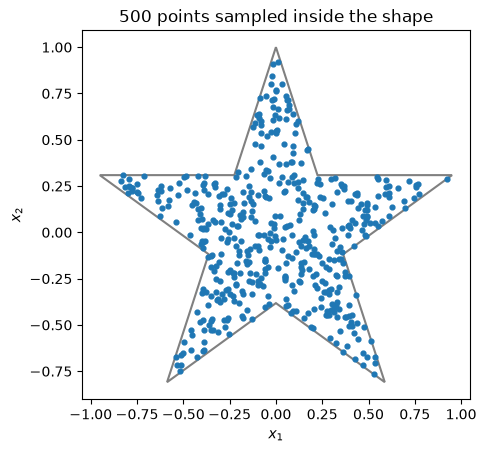

In [104]:
# The shape: any matplotlib patch works -- swap in one of the alternatives below
shape = PathPatch(Path.unit_regular_star(5, innerCircle=0.382))
# shape = Circle((0, 0), radius=1)
# shape = Ellipse((0, 0), width=2, height=1)
# shape = RegularPolygon((0, 0), numVertices=6, radius=1)

# The patch's path in data coordinates, and its bounding box
shape_path = shape.get_path().transformed(shape.get_transform())
(x0, y0), (x1, y1) = shape_path.get_extents().get_points()

n_datapts = 500
points = np.empty((0, 2))
while len(points) < n_datapts:
    cand = rng.uniform([x0, y0], [x1, y1], size=(4 * n_datapts, 2))
    points = np.vstack([points, cand[shape_path.contains_points(cand)]])
points = points[:n_datapts]

fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="gray", lw=1.5))
ax.scatter(points[:, 0], points[:, 1], s=12, color="tab:blue")
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(f"{n_datapts} points sampled inside the shape")
plt.show()

## Encode the points and take the mean

Each 2D point is mapped to an SSP vector. Averaging the embeddings bundles all
sampled locations into a single vector. The `length_scale` sets the width of
each point's similarity kernel — keep it small relative to the shape's size
(here the shape spans roughly 2 units).

In [105]:
ssp_space = HexagonalSSPSpace(domain_dim=2, ssp_dim=1015, length_scale=0.1, rng=0)

ssps = ssp_space.encode(points)  # (n_datapts, ssp_dim)
mean_ssp = ssps.mean(axis=0, keepdims=True)
ssps.shape, mean_ssp.shape

((500, 1015), (1, 1015))

## Similarity map of the mean SSP

Encode a grid covering the domain and take the dot product of each grid SSP
with the mean vector. The high-similarity region recovers the star.

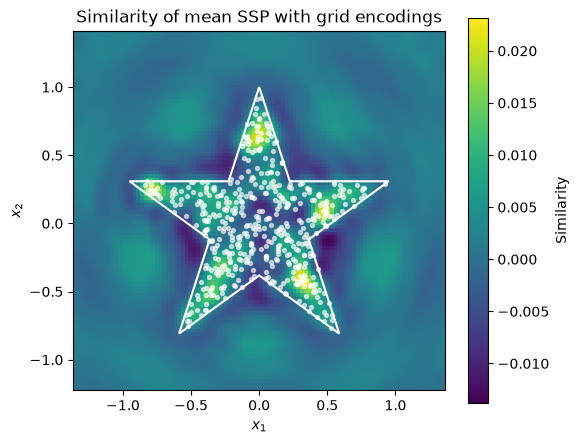

In [106]:

def get_grid(grid_n):
    pad = 0.4
    xs = np.linspace(x0 - pad, x1 + pad, grid_n)
    ys = np.linspace(y0 - pad, y1 + pad, grid_n)
    X, Y = np.meshgrid(xs, ys)
    grid_pts = np.column_stack([X.ravel(), Y.ravel()])
    return X,Y,grid_pts

grid_n = 100
X,Y,grid_pts = get_grid(grid_n) 
grid_ssps = ssp_space.encode(grid_pts)
sims = (grid_ssps @ mean_ssp.T).reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.pcolormesh(X, Y, sims, cmap="viridis", shading="auto")
ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="white", lw=1.5))
ax.scatter(points[:, 0], points[:, 1], s=8, color="white", alpha=0.6)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Similarity of mean SSP with grid encodings")
fig.colorbar(im, ax=ax, label="Similarity")
plt.show()

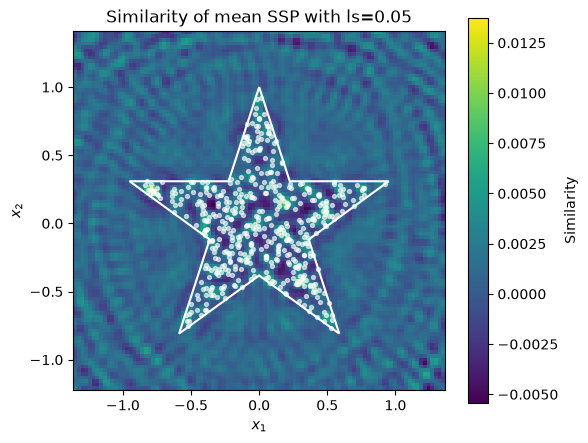

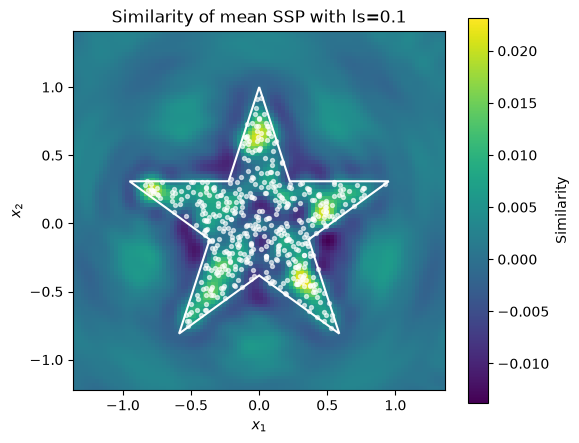

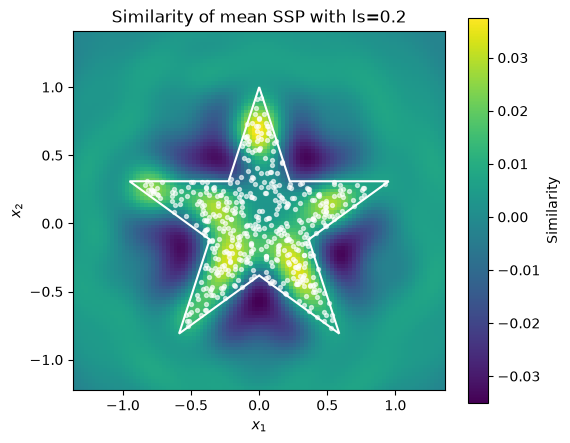

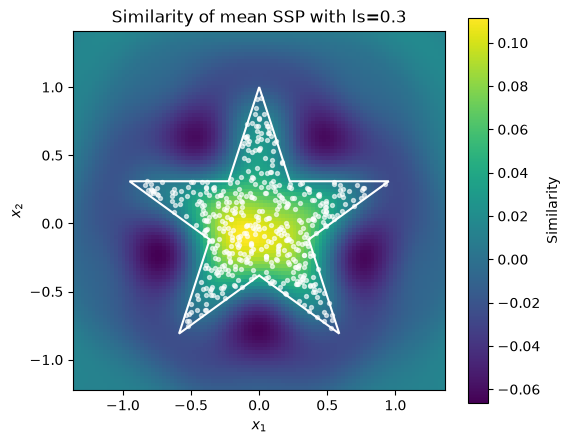

In [107]:
# Examples with different ls
def plot_shape(length_scale):
    ssp_space = HexagonalSSPSpace(domain_dim=2, ssp_dim=1015, length_scale=length_scale, rng=0)

    ssps = ssp_space.encode(points)  # (n_datapts, ssp_dim)
    mean_ssp = ssps.mean(axis=0, keepdims=True)
    
    grid_ssps = ssp_space.encode(grid_pts)
    sims = (grid_ssps @ mean_ssp.T).reshape(grid_n, grid_n)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.pcolormesh(X, Y, sims, cmap="viridis", shading="auto")
    ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="white", lw=1.5))
    ax.scatter(points[:, 0], points[:, 1], s=8, color="white", alpha=0.6)
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(f"Similarity of mean SSP with ls={length_scale}")
    fig.colorbar(im, ax=ax, label="Similarity")
    plt.show()

plot_shape(0.05)
plot_shape(0.1)
plot_shape(0.2)
plot_shape(0.3)


**Encoding.** A Hex-SSP maps $x\in\mathbb{R}^2$ to

$$\phi(x) = \mathcal{F}^{-1}\!\big[\exp(i\,A x)\big]\in\mathbb{R}^{d},$$

where $A$ is the `(ssp_dim, 2)` phase matrix. The kernel $k(x,x')=\phi(x)\cdot\phi(x')$ is
*stationary* (depends only on $x-x'$).

**Modulation.** Insert a per-frequency gain $g$ (a diagonal in the Fourier domain):

$$\tilde\phi(x) = \mathcal{F}^{-1}\!\big[\,g\odot\exp(i\,A x)\big].$$

If $g$ is constant we just reshape the (still stationary) kernel. If $g$ depends on **location**,
the kernel becomes non-stationary:

$$\tilde k(x,x') = \tfrac1d\sum_k g_k(x)\,g_k(x')\,e^{\,iA_k(x'-x)}.$$

We keep $g$ **block-constant across scales** and conjugate-symmetric (so $\tilde\phi$ stays real),
and then **renormalize** $\hat\phi = \tilde\phi/\lVert\tilde\phi\rVert$ so the gain only reshapes
each embedding's direction (its phase pattern) and never its magnitude. Similarities use the
normalized $\hat k(x,x') = \hat\phi(x)\cdot\hat\phi(x')\in[-1,1]$.

In [108]:
import jax
import jax.numpy as jnp
import optax

d = ssp_space.ssp_dim
n_scales = ssp_space.n_scales

# Scale block of each rfft half-spectrum coefficient: the phase matrix rows are
# [DC; K; -flip(K)] with K rotation-major and, within a rotation, the scales
# contiguous in groups of (domain_dim + 1) simplex phases.
blk = ssp_space.domain_dim + 1
scale_idx = np.tile(np.repeat(np.arange(n_scales), blk), ssp_space.n_rotates)
assert np.allclose(np.linalg.norm(ssp_space.phase_matrix[1:1 + (d - 1) // 2], axis=1),
                   ssp_space.scales[scale_idx])


def expand_gains(g_scales):
    """Expand per-scale gains (..., n_scales) to rfft half-spectrum gains
    (..., d//2 + 1), block-constant across scales, with the DC gain fixed at 1.
    Real gains on the half spectrum keep the modulated SSPs real."""
    dc = jnp.ones((*g_scales.shape[:-1], 1))
    return jnp.concatenate([dc, g_scales[..., scale_idx]], axis=-1)


def modulate(ssps, g):
    """Apply per-frequency gains g (real, rfft half-spectrum) to already-encoded
    SSP embeddings, then renormalize each vector to unit norm so the gain reshapes
    only the phase/direction of the kernel, never the magnitude:
        phi_tilde = irfft(g * rfft(phi)),   phi_tilde /= ||phi_tilde||."""
    mod = jnp.fft.irfft(g * jnp.fft.rfft(ssps, axis=-1), n=ssps.shape[-1], axis=-1)
    return mod / jnp.linalg.norm(mod, axis=-1, keepdims=True)


def nearest_pixels(pts, train_grid_n):
    """Flat indices (row-major, iy*train_grid_n + ix) of the get_grid(train_grid_n)
    cell nearest each point. Lets the same per-pixel gain field g index both the
    grid encodings and the sampled points that form the mean."""
    _, _, grid_pts = get_grid(train_grid_n)
    xs, ys = grid_pts[:train_grid_n, 0], grid_pts[::train_grid_n, 1]
    ix = np.rint((pts[:, 0] - xs[0]) / (xs[-1] - xs[0]) * (train_grid_n - 1))
    iy = np.rint((pts[:, 1] - ys[0]) / (ys[-1] - ys[0]) * (train_grid_n - 1))
    return jnp.asarray((np.clip(iy, 0, train_grid_n - 1) * train_grid_n
                        + np.clip(ix, 0, train_grid_n - 1)).astype(int))


# SSPs of the sampled shape points: resolution-independent, reused across runs
sampled_ssp_j = jnp.asarray(ssps, dtype=jnp.float32)

## Optimizing a location-dependent gain $g(x)$

The target is the ideal similarity map: 1 inside the shape, 0 everywhere else,
normalized to unit norm. We learn a **single** per-pixel gain field `g_grid`
(shape `(train_grid_n**2, n_scales)`) — one gain per scale block at every
training-grid pixel. The *same* field modulates both sides of the similarity:
every grid encoding, and every sampled point's encoding (via the pixel it lands
in) before the mean is taken. Each modulated encoding is **renormalized to unit
norm** (so $g$ acts on phase, not magnitude); write $\hat\phi_g(x)$ for that
unit vector. The modulated mean SSP $\tfrac1N\sum_i \hat\phi_g(x_i)$ is then
compared against $\hat\phi_g(x)$ at each grid location, and we minimize the
total squared error to the target with optax's Adam optimizer.

`train(train_grid_n)` runs the whole fit at a chosen training-grid resolution;
`compute_sims` then renders the learned field at any (finer) resolution. Below
we fit at `train_grid_n` = 10, 50, 100 and compare.

In [109]:
def train(train_grid_n, n_steps=300, learning_rate=1e-2):
    """Fit a per-pixel gain field on a train_grid_n x train_grid_n grid so the
    modulated (mean SSP vs grid SSP) similarity matches the shape target.
    Returns the fitted params and the loss history."""
    _, _, grid_pts = get_grid(train_grid_n)
    grid_ssps_j = jnp.asarray(ssp_space.encode(grid_pts), dtype=jnp.float32)

    # ideal similarity map: 1 inside the shape, 0 outside, unit norm
    target = shape_path.contains_points(grid_pts).astype(np.float32)
    target_j = jnp.asarray(target / np.linalg.norm(target))

    # nearest train pixel of every sampled point -> same g modulates mean & grid
    pt_pixel = nearest_pixels(points, train_grid_n)

    def loss_fn(params):
        g = expand_gains(params["g_grid"])                 # gain field, per pixel
        mod_grid = modulate(grid_ssps_j, g)                # scale grid encodings
        mod_mean = modulate(sampled_ssp_j, g[pt_pixel]).mean(axis=0, keepdims=True)
        sims = (mod_grid @ mod_mean.T).ravel()
        return jnp.sum((sims - target_j) ** 2)

    params = {"g_grid": jnp.ones((train_grid_n ** 2, n_scales))}
    optimizer = optax.adam(learning_rate=learning_rate)
    opt_state = optimizer.init(params)

    @jax.jit
    def step(params, opt_state):
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state)
        return optax.apply_updates(params, updates), opt_state, loss

    losses = np.empty(n_steps)
    for i in range(n_steps):
        params, opt_state, loss = step(params, opt_state)
        losses[i] = loss
    print(f"train_grid_n={train_grid_n:>3}: loss {losses[0]:.4f} -> {losses[-1]:.5f}")
    return params, losses

In [110]:
def compute_sims(grid_n, train_grid_n, g):
    """Similarity map at `grid_n` render resolution from a gain field
    `g = expand_gains(params["g_grid"])` optimized on a `train_grid_n` grid.
    Both grids share the same extent (get_grid), so sampled points and render
    pixels look up g at their nearest train cell -- a finer grid_n just renders
    the trained field at higher resolution."""
    # mean side (resolution-independent): modulate each sampled point, then average
    mod_mean = modulate(
        sampled_ssp_j, g[nearest_pixels(points, train_grid_n)]
    ).mean(axis=0, keepdims=True)

    # grid side: encode the render grid and modulate by g at each pixel's train cell
    _, _, plot_pts = get_grid(grid_n)
    plot_ssps = jnp.asarray(ssp_space.encode(plot_pts), dtype=jnp.float32)
    mod_grid = modulate(plot_ssps, g[nearest_pixels(plot_pts, train_grid_n)])
    return np.asarray(mod_grid @ mod_mean.T).reshape(grid_n, grid_n)

In [ ]:
# Fit at a few training-grid resolutions and render each at a common resolution
train_grid_ns = [10, 50, 100]
render_grid_n = 100
results = {n: train(n) for n in train_grid_ns}      # {train_grid_n: (params, losses)}

Xr, Yr, render_pts = get_grid(render_grid_n)
target_map = shape_path.contains_points(render_pts).astype(float).reshape(render_grid_n, render_grid_n)


def gain_magnitude(params, train_grid_n):
    """Per-pixel magnitude ||g|| of the learned n_scales gain vector, nearest-
    upsampled from the train_grid_n grid to render_grid_n -- so train_grid_n <
    render_grid_n shows as blocks (same nearest lookup compute_sims uses)."""
    g_mag = np.linalg.norm(np.asarray(params["g_grid"]), axis=1)     # (train_grid_n**2,)
    idx = np.asarray(nearest_pixels(render_pts, train_grid_n))
    return g_mag[idx].reshape(render_grid_n, render_grid_n)


ncols = len(train_grid_ns) + 1
fig, axs = plt.subplots(2, ncols, figsize=(4.8 * ncols, 8.6))

# Row 0: optimized similarity maps, with the target in the last column
for ax, n in zip(axs[0], train_grid_ns):
    params, _ = results[n]
    sims_opt = compute_sims(render_grid_n, n, expand_gains(params["g_grid"]))
    im = ax.pcolormesh(Xr, Yr, sims_opt, cmap="viridis", shading="auto")
    ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="white", lw=1))
    ax.set_aspect("equal")
    ax.set_title(f"similarity, train_grid_n = {n}")
    fig.colorbar(im, ax=ax)
im = axs[0, -1].pcolormesh(Xr, Yr, target_map, cmap="viridis", shading="auto")
axs[0, -1].add_patch(PathPatch(shape_path, facecolor="none", edgecolor="white", lw=1))
axs[0, -1].set_aspect("equal")
axs[0, -1].set_title("target")
fig.colorbar(im, ax=axs[0, -1])

# Row 1: magnitude of the learned per-pixel gain vector, ||g(x)|| over the
# n_scales gains (nearest-upsampled from the train grid)
for ax, n in zip(axs[1], train_grid_ns):
    params, _ = results[n]
    im = ax.pcolormesh(Xr, Yr, gain_magnitude(params, n), cmap="magma", shading="auto")
    ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="white", lw=1))
    ax.set_aspect("equal")
    ax.set_title(rf"$\|g(x)\|$ over scales, train_grid_n = {n}")
    fig.colorbar(im, ax=ax)
axs[1, -1].axis("off")   # no gain panel to pair with the target

plt.show()

train_grid_n= 10: loss 0.9681 -> 0.34855
train_grid_n= 50: loss 0.8629 -> 0.00405


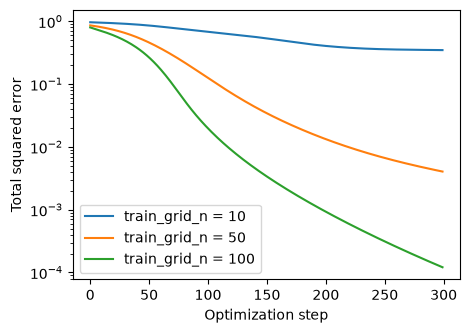

In [ ]:
# Loss curves: finer training grids have more free gains to fit the target
fig, ax = plt.subplots(figsize=(5, 3.5))
for n in train_grid_ns:
    ax.plot(results[n][1], label=f"train_grid_n = {n}")
ax.set_xlabel("Optimization step")
ax.set_ylabel("Total squared error")
ax.set_yscale("log")
ax.legend()
plt.show()

## Gaussian-over-scales gain: 2 parameters per pixel

Instead of a free gain per scale block, parameterize each pixel's gain across
the `n_scales` blocks as a discretized 1-D Gaussian and learn only its center
`mu` and width `sigma`:

$$g_k(x) = \exp\!\Big(-\tfrac12\big(\tfrac{k - \mu(x)}{\sigma(x)}\big)^2\Big),\qquad k = 0,\dots,\text{n\_scales}-1.$$

This shrinks the per-pixel parameters from `n_scales` (= 13) to **2** — `g_gauss`
has shape `(train_grid_n**2, 2)` — and makes the learned modulation a smooth
scale-band selector: `mu` picks which scale is emphasized, `sigma` how many
neighbouring scales come along. We reuse `expand_gains`, `modulate`, and
`compute_sims` unchanged, then plot the learned kernel at a few probe positions
(far outside the star, its middle, and just inside the boundary).

In [ ]:
def gauss_scale_gains(gp):
    """Per-scale gains from a discretized 1-D Gaussian over the n_scales blocks.
    gp[..., 0] = center mu (in scale-block index units), gp[..., 1] = raw width
    (sigma = softplus(raw) keeps it positive). Returns (..., n_scales)."""
    k = jnp.arange(n_scales)
    mu = gp[..., 0:1]
    sigma = jax.nn.softplus(gp[..., 1:2]) + 1e-3
    return jnp.exp(-0.5 * ((k - mu) / sigma) ** 2)


def train_gaussian(train_grid_n, n_steps=300, learning_rate=1e-2):
    """Like train(), but each pixel's across-scale gain is a Gaussian with only
    (mu, sigma) learned -> params are (train_grid_n**2, 2) instead of
    (train_grid_n**2, n_scales). Everything else (expand_gains, modulate,
    normalized similarity, target) is identical."""
    _, _, grid_pts = get_grid(train_grid_n)
    grid_ssps_j = jnp.asarray(ssp_space.encode(grid_pts), dtype=jnp.float32)
    target = shape_path.contains_points(grid_pts).astype(np.float32)
    target_j = jnp.asarray(target / np.linalg.norm(target))
    pt_pixel = nearest_pixels(points, train_grid_n)

    def loss_fn(params):
        g = expand_gains(gauss_scale_gains(params["g_gauss"]))
        mod_grid = modulate(grid_ssps_j, g)
        mod_mean = modulate(sampled_ssp_j, g[pt_pixel]).mean(axis=0, keepdims=True)
        sims = (mod_grid @ mod_mean.T).ravel()
        return jnp.sum((sims - target_j) ** 2)

    # init: center in the middle of the scale range, wide (near-flat) Gaussian
    mu0 = jnp.full((train_grid_n ** 2, 1), (n_scales - 1) / 2)
    raw0 = jnp.full((train_grid_n ** 2, 1), 5.0)          # softplus(5) ~ 5 blocks wide
    params = {"g_gauss": jnp.concatenate([mu0, raw0], axis=-1)}

    optimizer = optax.adam(learning_rate=learning_rate)
    opt_state = optimizer.init(params)

    @jax.jit
    def step(params, opt_state):
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state)
        return optax.apply_updates(params, updates), opt_state, loss

    losses = np.empty(n_steps)
    for i in range(n_steps):
        params, opt_state, loss = step(params, opt_state)
        losses[i] = loss
    print(f"[gauss] train_grid_n={train_grid_n:>3}: loss {losses[0]:.4f} -> {losses[-1]:.5f}")
    return params, losses

[gauss] train_grid_n= 50: loss 0.8761 -> 0.07921


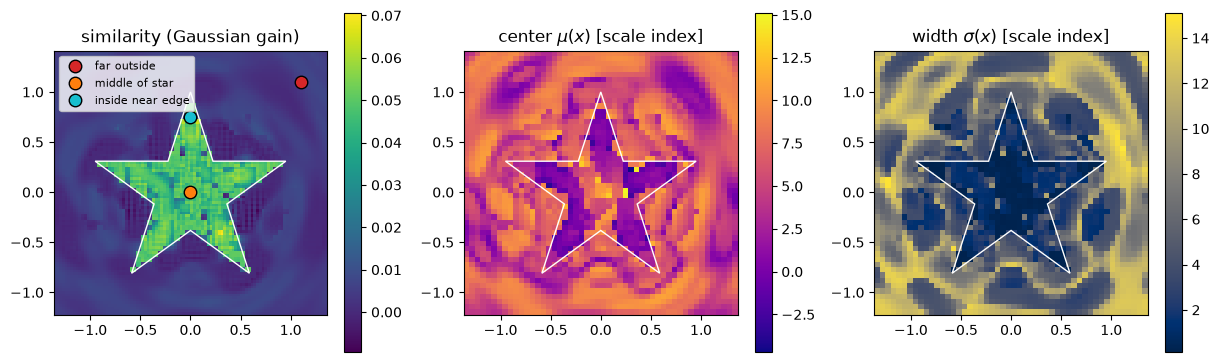

In [ ]:
# Fit the Gaussian-gain version at one training resolution and render it
# (fewer params/pixel -> needs more steps than the free per-scale version)
gtrain_grid_n = 50
gauss_params, gauss_losses = train_gaussian(gtrain_grid_n, n_steps=800)
gauss_g = expand_gains(gauss_scale_gains(gauss_params["g_gauss"]))
gauss_sims = compute_sims(render_grid_n, gtrain_grid_n, gauss_g)

# probe positions: far outside, middle of the star, and just inside the boundary
probes = ["far outside", "middle of star", "inside near edge"]
probe_pts = np.array([(1.1, 1.1), (0.0, 0.0), (0.0, 0.75)])
probe_colors = ["tab:red", "tab:orange", "tab:cyan"]

# learned mu(x) and sigma(x), nearest-upsampled to the render grid
gp = np.asarray(gauss_params["g_gauss"])
ridx = np.asarray(nearest_pixels(render_pts, gtrain_grid_n))
mu_field = gp[ridx, 0].reshape(render_grid_n, render_grid_n)
sigma_field = np.logaddexp(0, gp[ridx, 1]).reshape(render_grid_n, render_grid_n)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, data, title, cmap in [
        (axs[0], gauss_sims, "similarity (Gaussian gain)", "viridis"),
        (axs[1], mu_field, r"center $\mu(x)$ [scale index]", "plasma"),
        (axs[2], sigma_field, r"width $\sigma(x)$ [scale index]", "cividis")]:
    im = ax.pcolormesh(Xr, Yr, data, cmap=cmap, shading="auto")
    ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="white", lw=1))
    ax.set_aspect("equal")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
for label, p, c in zip(probes, probe_pts, probe_colors):
    axs[0].plot(*p, "o", color=c, ms=9, mec="black", label=label)
axs[0].legend(loc="upper left", fontsize=8)
plt.show()

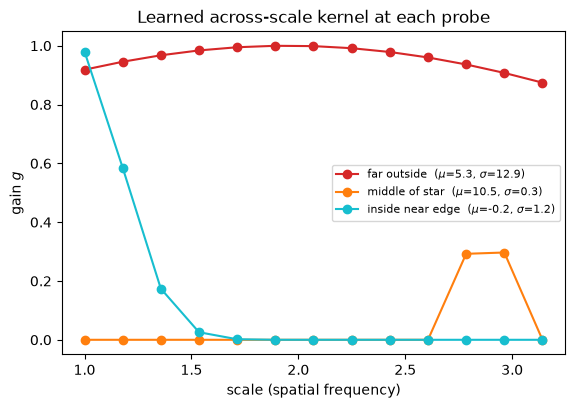

In [ ]:
# The learned across-scale Gaussian kernel at each probe position
probe_idx = np.asarray(nearest_pixels(probe_pts, gtrain_grid_n))
kernels = np.asarray(gauss_scale_gains(gauss_params["g_gauss"]))[probe_idx]  # (n_probe, n_scales)
scales = np.asarray(ssp_space.scales)
order = np.argsort(scales)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for i, (label, c) in enumerate(zip(probes, probe_colors)):
    mu, sigma = gp[probe_idx[i], 0], np.logaddexp(0, gp[probe_idx[i], 1])
    ax.plot(scales[order], kernels[i][order], "-o", color=c,
            label=f"{label}  ($\\mu$={mu:.1f}, $\\sigma$={sigma:.1f})")
ax.set_xlabel("scale (spatial frequency)")
ax.set_ylabel("gain $g$")
ax.set_title("Learned across-scale kernel at each probe")
ax.legend(fontsize=8)
plt.show()

## Effective kernel of each learned modulation

Each probe's learned gain is a single profile $g$ over the scales. Applying that
*one* profile uniformly to every grid point and to the $(0,0)$ encoding gives a
**translation-invariant** kernel $k_g(x) = \hat\phi_g(x)\cdot\hat\phi_g(0)$ — the
effective similarity "blob" that modulation induces. Emphasizing high scales
(fine detail) yields a tight kernel; emphasizing low scales yields a broad one,
so the three probe modulations should produce visibly different widths.

In [ ]:
# Effective (stationary) kernel induced by each probe's modulation: apply that
# ONE gain profile g uniformly to a grid AND to the (0,0) encoding, then take
# similarities. Same g everywhere -> translation-invariant "blob" centered at 0.
center_ssp = jnp.asarray(ssp_space.encode(np.array([[0.0, 0.0]])), dtype=jnp.float32)
render_ssps = jnp.asarray(ssp_space.encode(render_pts), dtype=jnp.float32)
probe_idx = np.asarray(nearest_pixels(probe_pts, gtrain_grid_n))
probe_gains = gauss_scale_gains(gauss_params["g_gauss"])[probe_idx]   # (n_probe, n_scales)

fig, axs = plt.subplots(1, len(probes), figsize=(5 * len(probes), 4.4))
for ax, label, c, g_scales in zip(axs, probes, probe_colors, probe_gains):
    g = expand_gains(g_scales)                        # this probe's full-spectrum gain
    mod_center = modulate(center_ssp, g)              # (1, d), unit norm
    kern = np.asarray(modulate(render_ssps, g) @ mod_center.T).reshape(render_grid_n, render_grid_n)
    im = ax.pcolormesh(Xr, Yr, kern, cmap="viridis", shading="auto")
    ax.add_patch(PathPatch(shape_path, facecolor="none", edgecolor="white", lw=1))
    ax.plot(0, 0, "o", color=c, ms=8, mec="black")
    ax.set_aspect("equal")
    ax.set_title(f"kernel: {label} modulation")
    fig.colorbar(im, ax=ax)
plt.show()